In [1]:
import numpy as np
import pandas as pd
from scipy.linalg import orthogonal_procrustes
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


THEME = 'BrBG'



df_og = pd.read_csv('../data/spiff_data-2.csv')
df_og = df_og.iloc[1450:]
df_og = df_og.replace(1000, np.nan)
df_original = df_og.drop(columns=['Unnamed: 0']).set_index('day')

# Calculate returns (price ratios Pt/Pt-1) as you did originally
df_og_returns = (df_original / df_original.shift(1) - 1).dropna() 
original_mean = df_og_returns.mean()
df_og_returns = df_og_returns - original_mean


# -------------------------------------------------
# 1. Your original parameters
# -------------------------------------------------
var_names = ['gurkor', 'guitars', 'slingshots', 'stocks', 'sugar', 'water', 'tranquillity']

# Factor loadings (7 observed x 7 latents)
Lambda_true = np.array([
    [-0.460493,  0.431975,  0.226305, -0.218470, -0.041653,  0.360676, -0.608752], # gurkor
    [ 0.494112,  0.212170,  0.095774, -0.260540, -0.236640,  0.685579,  0.328278], # guitars
    [ 0.441043,  0.204170,  0.094476, -0.485899, -0.347878, -0.561128, -0.287903], # slingshots
    [ 0.045350, -0.378985,  0.920457,  0.082476, -0.006300, -0.015188,  0.000779], # stocks
    [ 0.203079,  0.539617,  0.140728,  0.759331, -0.240474, -0.108821, -0.038918], # sugar
    [-0.469721,  0.408214,  0.206995, -0.237389, -0.099435, -0.257841,  0.661177], # water
    [ 0.292140,  0.353894,  0.144209, -0.092477,  0.868040, -0.080467,  0.009864]  # tranquillity
])

# VAR(2) coefficients (5 x 5)
# VAR(2) Lag 1 coefficients (7x7)
Phi1 = np.array([
    [ 0.066837, -0.047029, -0.032074, -0.129388, -0.120289, -0.162173,  0.029557], # F0 eq
    [ 0.123793, -0.006606,  0.033206, -0.265276, -0.075745,  0.035917, -0.058590], # F1 eq
    [ 0.026951,  0.015659,  0.000864, -0.045200, -0.024831,  0.035934, -0.043809], # F2 eq
    [ 0.199106,  0.007784,  0.014711, -0.220926, -0.061257, -0.002547,  0.039002], # F3 eq
    [-0.032751, -0.034423,  0.000487,  0.013779, -0.016192, -0.075896, -0.035988], # F4 eq
    [ 0.016032, -0.018288, -0.006550, -0.033598, -0.052375, -0.296606, -0.023336], # F5 eq
    [-0.014400, -0.001650,  0.021113, -0.040414,  0.006551,  0.035195, -0.182736]  # F6 eq
])

# VAR(2) Lag 2 coefficients (7x7)
Phi2 = np.array([
    [ 0.018276, -0.036829,  0.023368, -0.076605,  0.003404, -0.084637, -0.044700], # F0 eq
    [ 0.040158, -0.042788,  0.016656, -0.044778,  0.012176,  0.000934, -0.006445], # F1 eq
    [ 0.010401, -0.001657, -0.015511, -0.017275, -0.028722, -0.011827,  0.032037], # F2 eq
    [ 0.019280, -0.000785, -0.004241, -0.047150,  0.031045,  0.018171, -0.054329], # F3 eq
    [ 0.005180,  0.028481,  0.002092,  0.008334, -0.009077,  0.014023, -0.009718], # F4 eq
    [ 0.011509, -0.018017, -0.012928,  0.000614,  0.004906, -0.070937,  0.004123], # F5 eq
    [-0.004617,  0.034619,  0.008011, -0.010612, -0.000637,  0.029500, -0.061284]  # F6 eq
])

# Pruned VAR(2) Lag 1 coefficients (7x7)
# Removed: F0->F1, F1->F1, F2->F1, F4->F1, F2->F2, F4->F2, etc.
# Phi1 = np.array([
#     [ 0.066837,  0.000000,  0.000000, -0.129388, -0.120289, -0.162173,  0.000000], # F0 eq
#     [ 0.123793,  0.000000,  0.033206, -0.265276, -0.075745,  0.000000, -0.058590], # F1 eq
#     [ 0.026951,  0.000000,  0.000000, -0.045200,  0.000000,  0.000000,  0.000000], # F2 eq
#     [ 0.199106,  0.000000,  0.000000, -0.220926, -0.061257,  0.000000,  0.000000], # F3 eq
#     [-0.032751, -0.034423,  0.000000,  0.000000,  0.000000, -0.075896,  0.000000], # F4 eq
#     [ 0.016032,  0.000000,  0.000000, -0.033598, -0.052375, -0.296606,  0.000000], # F5 eq
#     [-0.014400,  0.000000,  0.021113, -0.040414,  0.000000,  0.035195, -0.182736]  # F6 eq
# ])

# # Pruned VAR(2) Lag 2 coefficients (7x7)
# Phi2 = np.array([
#     [ 0.000000,  0.000000,  0.000000, -0.076605,  0.000000, -0.084637,  0.000000], # F0 eq
#     [ 0.040158, -0.042788,  0.000000, -0.044778,  0.000000,  0.000000,  0.000000], # F1 eq
#     [ 0.000000,  0.000000,  0.000000,  0.000000,  0.000000,  0.000000,  0.000000], # F2 eq
#     [ 0.000000,  0.000000,  0.000000, -0.047150,  0.031045,  0.000000, -0.054329], # F3 eq
#     [ 0.000000,  0.028481,  0.000000,  0.000000,  0.000000,  0.000000,  0.000000], # F4 eq
#     [ 0.000000,  0.000000,  0.000000,  0.000000,  0.000000, -0.070937,  0.000000], # F5 eq
#     [ 0.000000,  0.034619,  0.000000,  0.000000,  0.000000,  0.000000, -0.061284]  # F6 eq
# ])


from numpy.linalg import eigh

og_corr = df_og_returns.corr().values  # 7x7

# Eigendecomposition of the correlation matrix
eigenvalues, eigenvectors = eigh(og_corr)

# Sort descending
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Lambda that reproduces correlations: Λ @ Λ.T = Σ
# Each column scaled by sqrt(eigenvalue)
Lambda_corrected = eigenvectors * np.sqrt(eigenvalues)

print("Implied correlation from corrected Lambda:")
print(np.round(Lambda_corrected @ Lambda_corrected.T, 3))


# -------------------------------------------------
# 2. Simulate the true factors from VAR(2)
# -------------------------------------------------
np.random.seed(69)
T = 4000
burn = 500
F = np.zeros((T, 7))


for t in range(2, T):
    F[t] = Phi1 @ F[t-1] + Phi2 @ F[t-2] + np.random.randn(7)

F = F[burn:]  # stationary sample

# -------------------------------------------------
# 3. Generate observed data (no idiosyncratic noise for verification)
#    Y = F @ Lambda_true.T
# -------------------------------------------------
idiosyncratic_std = 0.05 # Blev sämre av noise...
noise = np.random.randn(len(F), 7) * idiosyncratic_std

Y = F @ Lambda_corrected.T + noise
df_sim = pd.DataFrame(Y, columns=var_names)


# Z-score to match your original preprocessing
# df_sim = pd.DataFrame(StandardScaler().fit_transform(df_sim), columns=var_names)

# -------------------------------------------------
# 4. Re-extract factors via PCA (as you presumably did originally)
# -------------------------------------------------
pca = PCA(n_components=7)
F_est = pca.fit_transform(df_sim)          # (T x 5) scores
Lambda_est = pca.components_.T             # (7 x 5) loadings

# -------------------------------------------------
# 5. PROCRUSTES ALIGNMENT (the missing step)
# -------------------------------------------------
# Find rotation matrix R that minimizes ||F - F_est @ R||_F
R, _ = orthogonal_procrustes(F_est, F)     # Note: (estimated, target)

# Apply rotation to factors and loadings
F_aligned = F_est @ R
Lambda_aligned = Lambda_est @ R

# Fix sign ambiguity (flip signs to match original where possible)
signs = np.sign(np.diag(Lambda_aligned.T @ Lambda_corrected))
Lambda_aligned = Lambda_aligned * signs
F_aligned = F_aligned * signs

# -------------------------------------------------
# 6. Compare
# -------------------------------------------------
print("Original Loadings:")
print(pd.DataFrame(Lambda_corrected, index=var_names, columns=[f"F{i}" for i in range(7)]))
print("\nAligned Simulated Loadings:")
print(pd.DataFrame(np.round(Lambda_aligned, 6), index=var_names, columns=[f"F{i}" for i in range(7)]))

# Check correlation between true and aligned factors (should be ~1)
print("\nCorrelation between true and aligned factors:")
print(np.diag(np.corrcoef(F.T, F_aligned.T)[:7, 7:]).round(4))

Implied correlation from corrected Lambda:
[[ 1.    -0.326 -0.291 -0.045 -0.081  0.623 -0.148]
 [-0.326  1.     0.553  0.028  0.216 -0.369  0.269]
 [-0.291  0.553  1.     0.018  0.127 -0.259  0.21 ]
 [-0.045  0.028  0.018  1.    -0.021 -0.05   0.002]
 [-0.081  0.216  0.127 -0.021  1.    -0.091  0.142]
 [ 0.623 -0.369 -0.259 -0.05  -0.091  1.    -0.18 ]
 [-0.148  0.269  0.21   0.002  0.142 -0.18   1.   ]]
Original Loadings:
                    F0        F1        F2        F3        F4        F5  \
gurkor       -0.713171  0.454613  0.225253 -0.203421 -0.039046 -0.240568   
guitars       0.765309  0.223492  0.095863 -0.242347 -0.216908 -0.459444   
slingshots    0.682956  0.215826  0.096077 -0.452786 -0.318953  0.376324   
stocks        0.069536 -0.400830  0.910010  0.079113 -0.004852  0.009898   
sugar         0.313867  0.566307  0.138483  0.713587 -0.215796  0.072806   
water        -0.727842  0.429125  0.205859 -0.220627 -0.091871  0.171401   
tranquillity  0.451525  0.372601  0.14340

Original returns standard deviations:
gurkor          0.004068
guitars         0.016023
slingshots      0.016352
stocks          0.014869
sugar           0.015781
water           0.003534
tranquillity    0.013334
dtype: float64

Simulated standardized returns (should be ~N(0,1)):
gurkor          1.032282
guitars         1.011464
slingshots      1.032395
stocks          1.000367
sugar           1.095019
water           1.006540
tranquillity    1.026913
dtype: float64

Simulated returns volatilities (should match original):
gurkor          0.004068
guitars         0.016023
slingshots      0.016352
stocks          0.014869
sugar           0.015781
water           0.003534
tranquillity    0.013334
dtype: float64


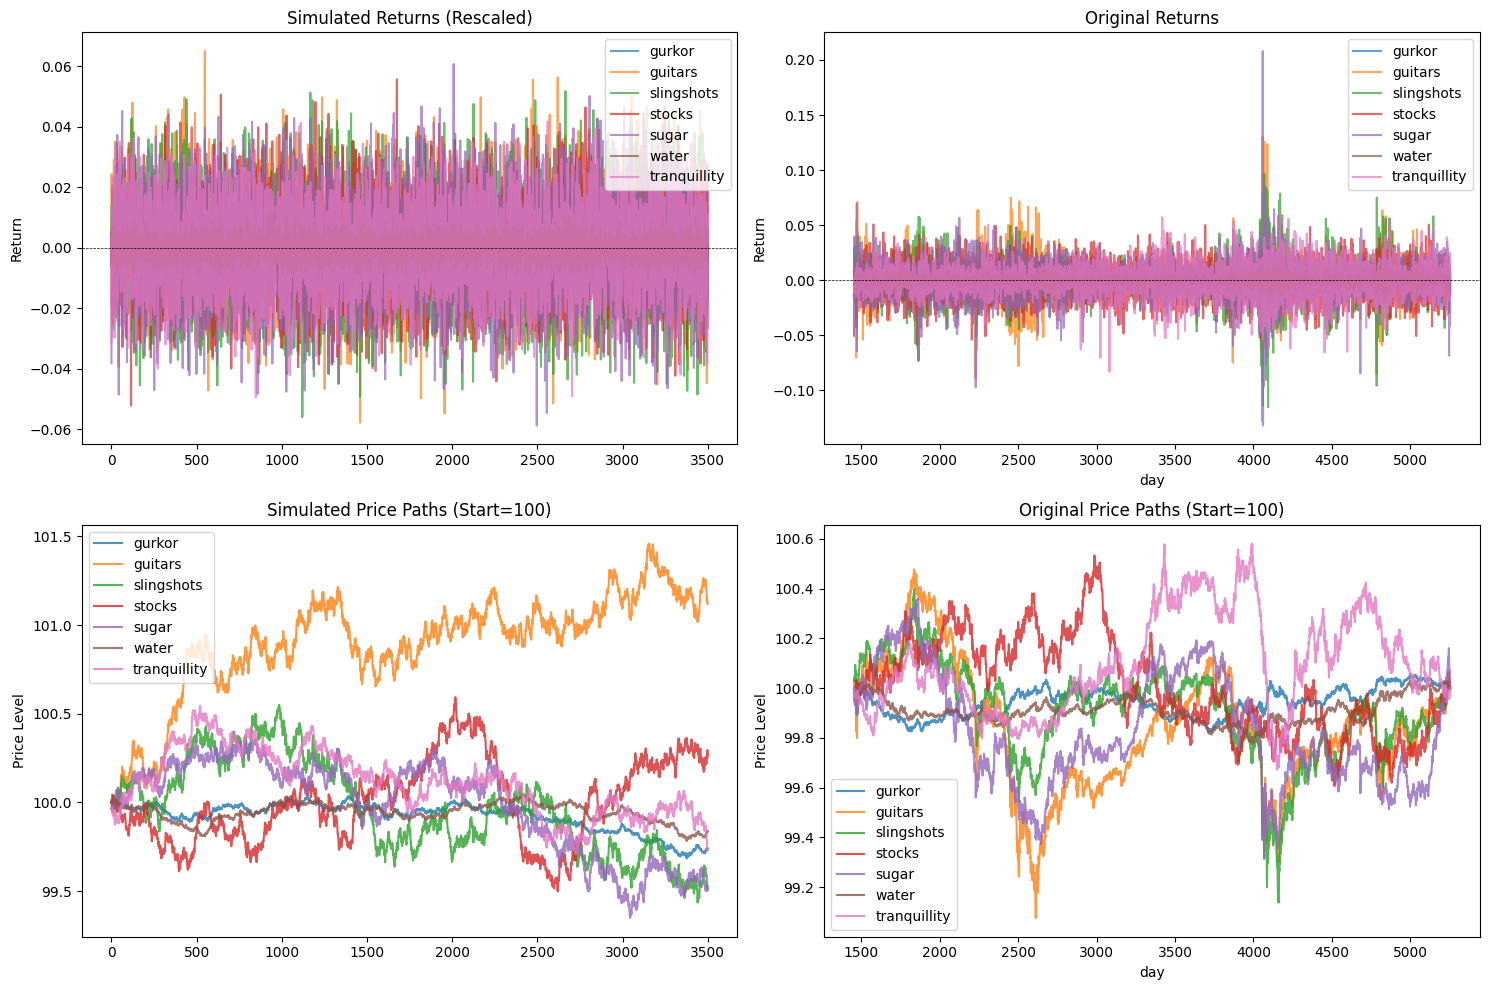


Volatility comparison (Original vs Simulated):
              Original  Simulated  Ratio
gurkor          0.0041     0.0041    1.0
guitars         0.0160     0.0160    1.0
slingshots      0.0164     0.0164    1.0
stocks          0.0149     0.0149    1.0
sugar           0.0158     0.0158    1.0
water           0.0035     0.0035    1.0
tranquillity    0.0133     0.0133    1.0


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import orthogonal_procrustes
from sklearn.decomposition import PCA

var_names = ['gurkor', 'guitars', 'slingshots', 'stocks', 'sugar', 'water', 'tranquillity']

# -------------------------------------------------
# 1. Load original data and get scaling parameters
# -------------------------------------------------

# Get standard deviations (for rescaling the simulation back)
original_stds = df_og_returns.std()
print("Original returns standard deviations:")
print(original_stds)

# -------------------------------------------------
# 2. Define your factor model parameters
# # -------------------------------------------------
# Lambda_true = np.array([
#     [-0.460493,  0.431975,  0.226305, -0.218470, -0.041653],
#     [ 0.494112,  0.212170,  0.095774, -0.260540, -0.236640],
#     [ 0.441043,  0.204170,  0.094476, -0.485899, -0.347878],
#     [ 0.045350, -0.378985,  0.920457,  0.082476, -0.006300],
#     [ 0.203079,  0.539617,  0.140728,  0.759331, -0.240474],
#     [-0.469721,  0.408214,  0.206995, -0.237389, -0.099435],
#     [ 0.292140,  0.353894,  0.144209, -0.092477,  0.868040]
# ])

# Phi1 = np.array([
#     [ 0.069570, -0.045041, -0.032271, -0.126121, -0.116237],
#     [ 0.123517, -0.006882,  0.033199, -0.266336, -0.075593],
#     [ 0.027233,  0.014420, -0.000103, -0.045385, -0.024730],
#     [ 0.198330,  0.008947,  0.016066, -0.222132, -0.061226],
#     [-0.032710, -0.032482,  0.001286,  0.015577, -0.016760]
# ])

# Phi2 = np.array([
#     [ 0.013774, -0.033803,  0.025312, -0.071823,  0.012382],
#     [ 0.042048, -0.043486,  0.014998, -0.043731,  0.009972],
#     [ 0.011989, -0.002305, -0.016781, -0.016861, -0.030828],
#     [ 0.018717, -0.000719, -0.003339, -0.048658,  0.031319],
#     [ 0.003668,  0.029666,  0.001740,  0.012825, -0.005191]
# ])

# # -------------------------------------------------
# # 3. Simulate VAR(2) factors (same as your original)
# # -------------------------------------------------
# np.random.seed(42)
# T = 4000
# burn = 500
# F = np.zeros((T, 5))

# for t in range(2, T):
#     F[t] = Phi1 @ F[t-1] + Phi2 @ F[t-2] + np.random.randn(5)

# F = F[burn:]  # Stationary sample

# -------------------------------------------------
# 4. Reconstruct standardized returns from factors
# -------------------------------------------------
# This gives you z-scored returns (mean 0, std 1) because factors are N(0,1) and loadings are orthogonal
Y_std = Y
df_recon_std = pd.DataFrame(Y_std, columns=var_names)
print("\nSimulated standardized returns (should be ~N(0,1)):")
print(df_recon_std.std())
# -------------------------------------------------
# 5. STANDARDIZE simulated returns first, then rescale to original volatility
# -------------------------------------------------
# Y_std currently has variance = sum of squared loadings per row (not 1)
Y_current_stds = pd.DataFrame(Y, columns=var_names).std()

df_returns_sim = pd.DataFrame(Y, columns=var_names).multiply(
    original_stds / Y_current_stds, axis=1
)


print("\nSimulated returns volatilities (should match original):")
print(df_returns_sim.std())

# -------------------------------------------------
# 6. Accumulate to price series (start at 100)
# -------------------------------------------------
start_value = 100
df_prices_sim = start_value + df_returns_sim.cumsum()
df_prices_original = start_value + df_og_returns.cumsum()

# -------------------------------------------------
# 7. Plot comparison
# -------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Simulated returns (rescaled to original volatility)
df_returns_sim.plot(ax=axes[0,0], alpha=0.7, title='Simulated Returns (Rescaled)')
axes[0,0].axhline(0, color='black', linestyle='--', linewidth=0.5)
axes[0,0].set_ylabel('Return')

# Plot 2: Original returns
df_og_returns.plot(ax=axes[0,1], alpha=0.7, title='Original Returns')
axes[0,1].axhline(0, color='black', linestyle='--', linewidth=0.5)
axes[0,1].set_ylabel('Return')

# Plot 3: Simulated prices (cumsum)
df_prices_sim.plot(ax=axes[1,0], alpha=0.8, title='Simulated Price Paths (Start=100)')
axes[1,0].set_ylabel('Price Level')

# Plot 4: Original prices (cumsum)
df_prices_original.plot(ax=axes[1,1], alpha=0.8, title='Original Price Paths (Start=100)')
axes[1,1].set_ylabel('Price Level')

plt.tight_layout()
plt.show()

# -------------------------------------------------
# 8. Validation: Volatility comparison
# -------------------------------------------------
print("\nVolatility comparison (Original vs Simulated):")
comparison = pd.DataFrame({
    'Original': original_stds,
    'Simulated': df_returns_sim.std(),
    'Ratio': df_returns_sim.std() / original_stds
})
print(comparison.round(4))

In [64]:
# What your model implies for the correlation of observed variables
F_cov = np.cov(F.T)  # 7x7 factor covariance
Y_cov_implied = Lambda_true @ F_cov @ Lambda_true.T
Y_corr_implied = np.corrcoef(Y.T)

print("Implied correlation between gurkor and guitars:")
print(Y_corr_implied[0, 1])  # should match original data

Implied correlation between gurkor and guitars:
-0.3199413247490027


In [65]:
og_corr = df_og_returns.corr()
sim_corr = pd.DataFrame(Y_corr_implied, index=var_names, columns=var_names)

# Side by side
print("Original:\n", og_corr.round(3))
print("\nSimulated:\n", sim_corr.round(3))

Original:
               gurkor  guitars  slingshots  stocks  sugar  water  tranquillity
gurkor         1.000   -0.326      -0.291  -0.045 -0.081  0.623        -0.148
guitars       -0.326    1.000       0.553   0.028  0.216 -0.369         0.269
slingshots    -0.291    0.553       1.000   0.018  0.127 -0.259         0.210
stocks        -0.045    0.028       0.018   1.000 -0.021 -0.050         0.002
sugar         -0.081    0.216       0.127  -0.021  1.000 -0.091         0.142
water          0.623   -0.369      -0.259  -0.050 -0.091  1.000        -0.180
tranquillity  -0.148    0.269       0.210   0.002  0.142 -0.180         1.000

Simulated:
               gurkor  guitars  slingshots  stocks  sugar  water  tranquillity
gurkor         1.000   -0.320      -0.315  -0.059 -0.067  0.605        -0.181
guitars       -0.320    1.000       0.552   0.040  0.223 -0.365         0.267
slingshots    -0.315    0.552       1.000   0.027  0.161 -0.266         0.248
stocks        -0.059    0.040       0.02

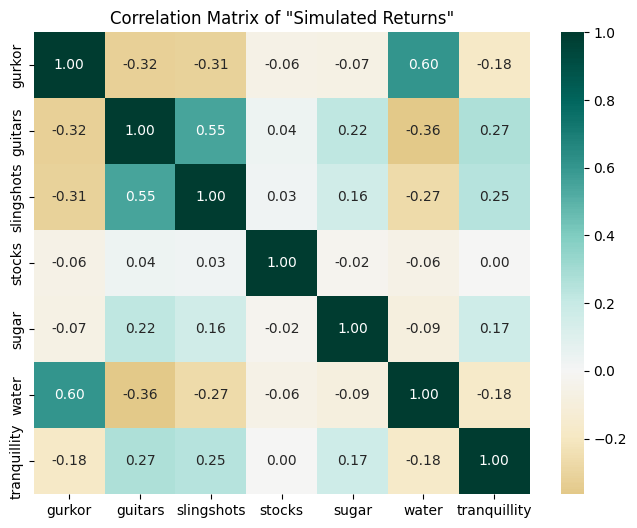

=============================== SIMULATED RETURNS PCA ================================


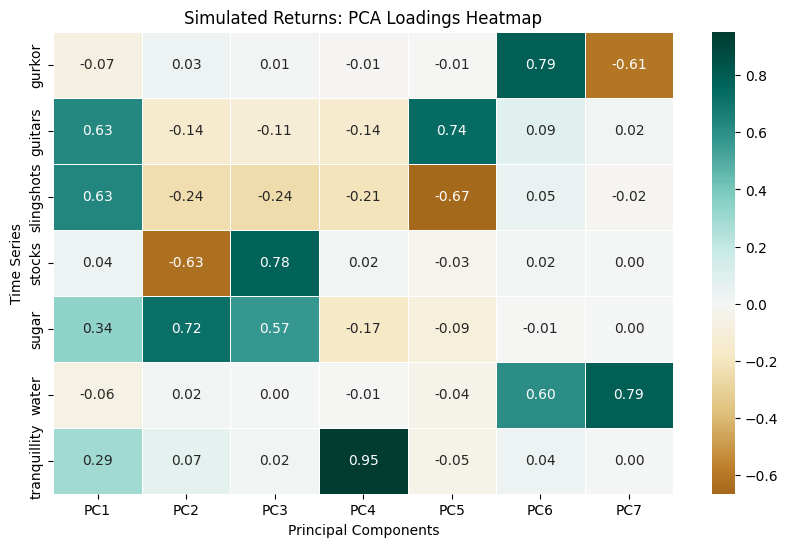

Explained Variance Ratio per Component:
PC1: 0.3856 (38.56%)
PC2: 0.1936 (19.36%)
PC3: 0.1777 (17.77%)
PC4: 0.1258 (12.58%)
PC5: 0.0967 (9.67%)
PC6: 0.0160 (1.60%)
PC7: 0.0046 (0.46%)

Cumulative Variance Explained by top 3 components: 75.69%


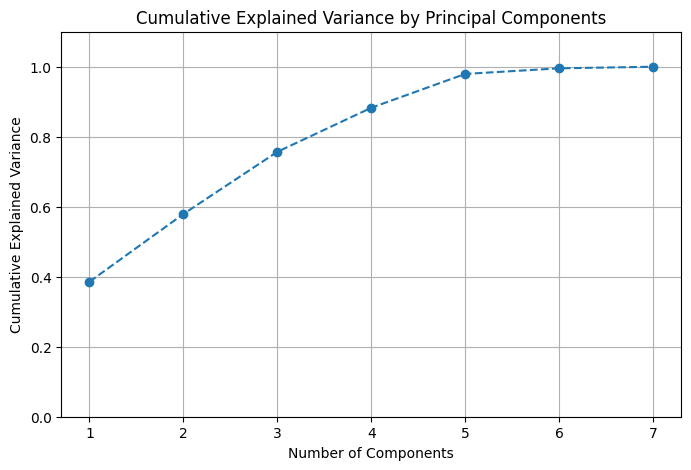

=== PRINCIPAL COMPONENT DRIVERS ===

PC1 is primarily driven by:
  slingshots      | Weight:  0.6298 | 🟢 Positive
  guitars         | Weight:  0.6284 | 🟢 Positive
  sugar           | Weight:  0.3374 | 🟢 Positive
  tranquillity    | Weight:  0.2912 | 🟢 Positive

PC2 is primarily driven by:
  sugar           | Weight:  0.7224 | 🟢 Positive
  stocks          | Weight: -0.6287 | 🔴 Negative

PC3 is primarily driven by:
  stocks          | Weight:  0.7758 | 🟢 Positive
  sugar           | Weight:  0.5701 | 🟢 Positive


--- Simulated Returns Variance Explained ---
Top 3 components explain: 75.69%

PCA Loadings (How much each series contributes to each PC):
                   PC1       PC2       PC3       PC4       PC5       PC6  \
gurkor       -0.069957  0.030360  0.010745 -0.010475 -0.007971  0.789781   
guitars       0.628395 -0.142395 -0.112711 -0.143665  0.737319  0.085699   
slingshots    0.629782 -0.236897 -0.244642 -0.206336 -0.665115  0.047165   
stocks        0.035623 -0.628706  0.7757

In [70]:

import seaborn as sns

# Calculate Returns and align metadata

# --- 2. CORRELATION ANALYSIS ---
plt.figure(figsize=(8, 6))
sns.heatmap(df_returns_sim.corr(), annot=True, cmap=THEME, center=0, fmt=".2f")
plt.title('Correlation Matrix of "Simulated Returns"')
plt.show()

# --- 3. PCA FUNCTION ---
# Building a function keeps your code DRY (Don't Repeat Yourself) 
# and prevents variable overwriting.
def run_and_plot_pca(data, title_prefix):
    # Standardize
    #scaler = StandardScaler()
    #scaled_data = scaler.fit_transform(data)
    scaled_data = data
    # Fit PCA
    pca = PCA()
    pca.fit(scaled_data)
    
    # Loadings extraction
    loadings_df = pd.DataFrame(
        pca.components_.T, 
        columns=[f'PC{i+1}' for i in range(pca.n_components_)], 
        index=data.columns
    )
    
    # Plot Heatmap
    plt.figure(figsize=(10, 6))
    sns.heatmap(loadings_df, annot=True, cmap=THEME, center=0, fmt=".2f", linewidths=0.5)
    plt.title(f'{title_prefix}: PCA Loadings Heatmap')
    plt.xlabel('Principal Components')
    plt.ylabel('Time Series')
    plt.show()

    # explained var
    explained_variance = pca.explained_variance_ratio_
    cumulative_variance = np.cumsum(explained_variance)

    print("Explained Variance Ratio per Component:")
    for i, var in enumerate(explained_variance):
        print(f"PC{i+1}: {var:.4f} ({var*100:.2f}%)")

    print(f"\nCumulative Variance Explained by top 3 components: {cumulative_variance[2]*100:.2f}%")

    # Plot the Scree Plot
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, 8), cumulative_variance, marker='o', linestyle='--')
    plt.title('Cumulative Explained Variance by Principal Components')
    plt.xlabel('Number of Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.grid(True)
    plt.ylim(0, 1.1)
    plt.show()

    print("=== PRINCIPAL COMPONENT DRIVERS ===")
    for pc in ['PC1', 'PC2', 'PC3']:
        print(f"\n{pc} is primarily driven by:")
        
        # Sort the features by their absolute contribution to this PC
        sorted_features = loadings_df[pc].abs().sort_values(ascending=False)
        
        for feature, abs_weight in sorted_features.items():
            actual_weight = loadings_df.loc[feature, pc]
            
            # Threshold: We only print features that have a meaningful impact (e.g., > 0.3)
            # Loadings are constrained between -1 and 1.
            if abs_weight > 0.25:
                direction = "🟢 Positive" if actual_weight > 0 else "🔴 Negative"
                print(f"  {feature:<15} | Weight: {actual_weight:>7.4f} | {direction}")

    print("\n" + "="*35 + "\n")
    
    # Variance Explained
    cumulative_var = np.cumsum(pca.explained_variance_ratio_)
    print(f"--- {title_prefix} Variance Explained ---")
    print(f"Top 3 components explain: {cumulative_var[2]*100:.2f}%\n")

    loadings = pd.DataFrame(
    pca.components_.T,  # Transpose the matrix
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=data.columns # Your original 7 column names
)

    print("PCA Loadings (How much each series contributes to each PC):")
    print(loadings)
    
    return pca, loadings_df

# --- 4. EXECUTE COMPARISON ---

print(80*"=")
print(f'{31* '='} SIMULATED RETURNS PCA {32* '='}')
print(80*"=")
pca_returns, loadings_returns = run_and_plot_pca(df_returns_sim, "Simulated Returns")

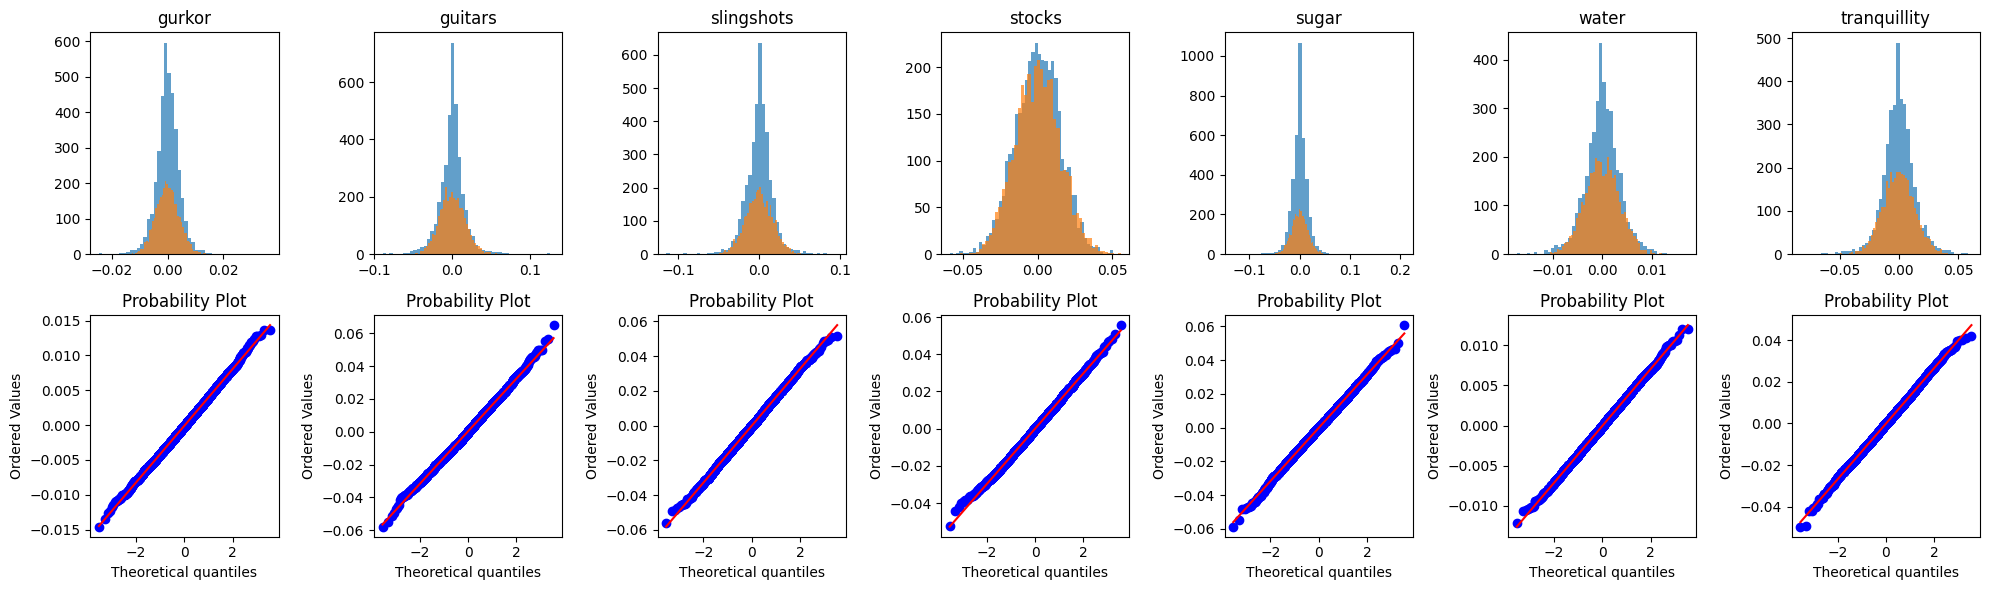

gurkor: skew -0.06 vs 0.08 | kurt 3.62 vs -0.01
guitars: skew 0.21 vs 0.11 | kurt 5.75 vs 0.01
slingshots: skew -0.21 vs 0.01 | kurt 4.70 vs -0.12
stocks: skew -0.09 vs 0.09 | kurt 0.05 vs -0.12
sugar: skew 0.03 vs -0.02 | kurt 13.47 vs 0.11
water: skew -0.14 vs 0.02 | kurt 1.64 vs -0.08
tranquillity: skew -0.20 vs 0.02 | kurt 2.59 vs -0.00


In [67]:
from scipy import stats

fig, axes = plt.subplots(2, 7, figsize=(20, 6))
for i, col in enumerate(var_names):
    axes[0, i].hist(df_og_returns[col], bins=50, alpha=0.7, label='Original')
    axes[0, i].hist(df_returns_sim[col], bins=50, alpha=0.7, label='Simulated')
    axes[0, i].set_title(col)
    
    # QQ plot
    stats.probplot(df_returns_sim[col], plot=axes[1, i])
plt.tight_layout()
plt.show()

# Moments comparison
for col in var_names:
    print(f"{col}: skew {df_og_returns[col].skew():.2f} vs {df_returns_sim[col].skew():.2f} | "
          f"kurt {df_og_returns[col].kurt():.2f} vs {df_returns_sim[col].kurt():.2f}")

Detta gav oss att vi inte skulle ha Gaussian shocks! Måste ju fånga tailen!

In [68]:
# If squared returns are autocorrelated, there's volatility clustering
from statsmodels.stats.diagnostic import acorr_ljungbox

for col in var_names:
    lb = acorr_ljungbox(df_og_returns[col]**2, lags=10, return_df=True)
    print(f"{col}: Ljung-Box p-value (squared returns) = {lb['lb_pvalue'].min():.4f}")
# p < 0.05 means significant volatility clustering

gurkor: Ljung-Box p-value (squared returns) = 0.0000
guitars: Ljung-Box p-value (squared returns) = 0.0000
slingshots: Ljung-Box p-value (squared returns) = 0.0000
stocks: Ljung-Box p-value (squared returns) = 0.2506
sugar: Ljung-Box p-value (squared returns) = 0.0000
water: Ljung-Box p-value (squared returns) = 0.0000
tranquillity: Ljung-Box p-value (squared returns) = 0.0000


In [71]:
"""
Nästa steg: fixa kurtosis och vol clustering!
"""

'\nNästa steg: fixa kurtosis och vol clustering!\n'

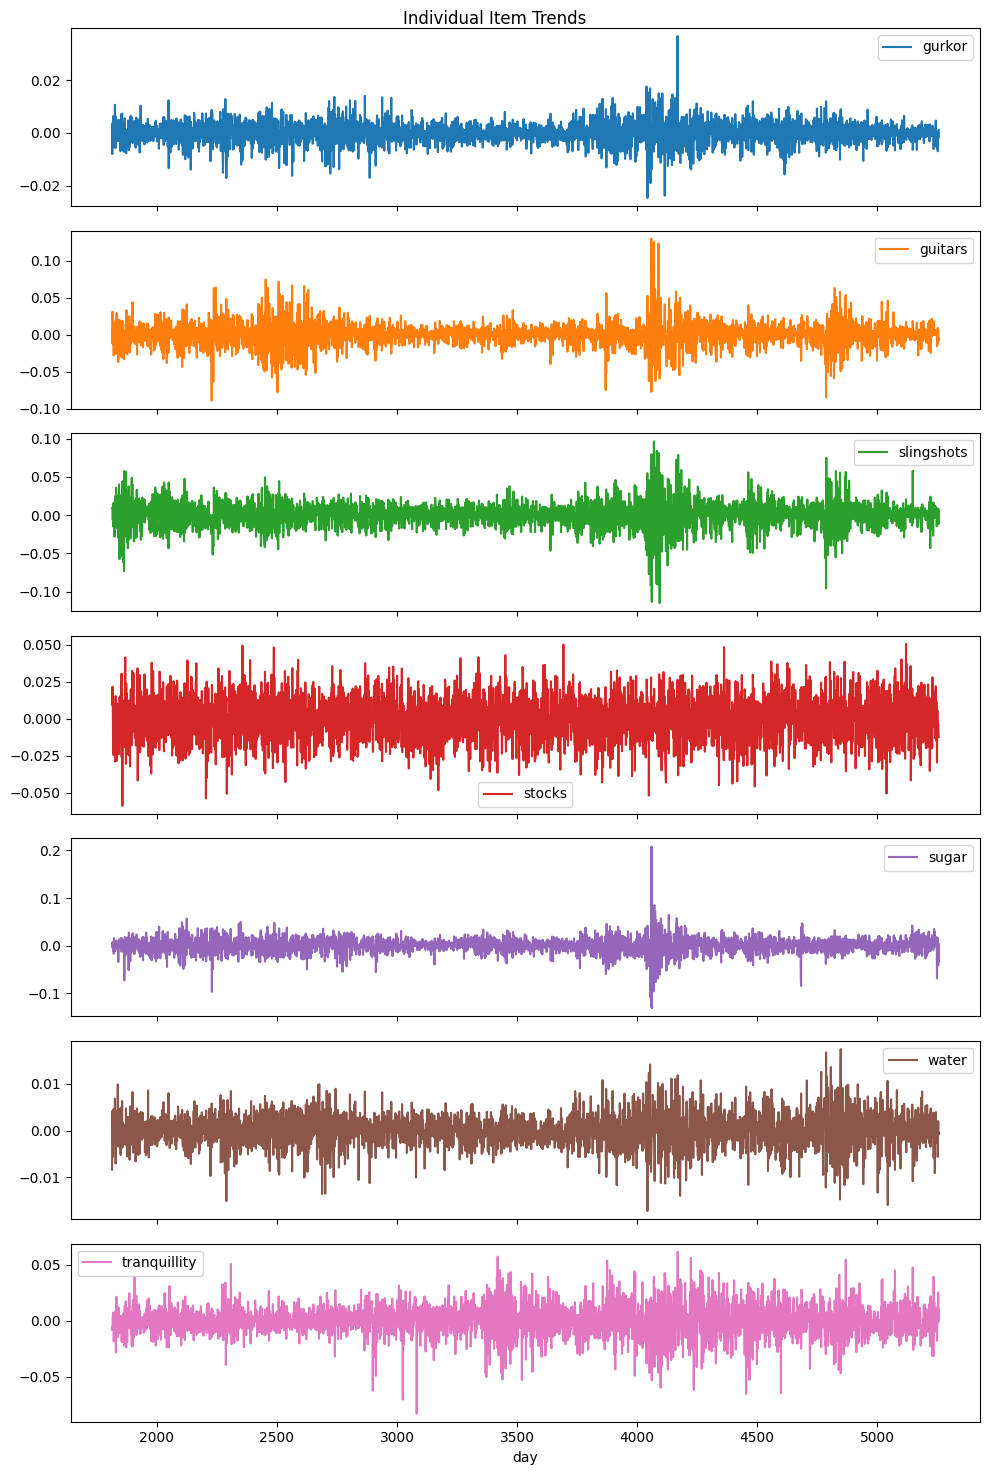

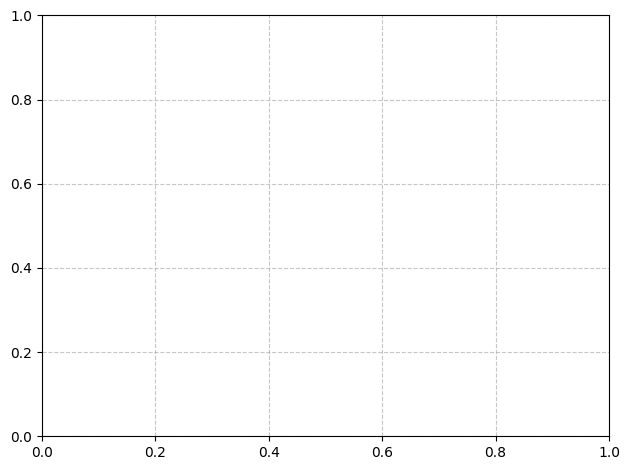

In [ ]:
plot_df = df_og_returns[1450:]

plot_df.plot(subplots=True, figsize=(10, 15), title="Individual Item Trends")
plt.tight_layout()
plt.show()

# 3. Customize the labels and appearance

# Move the legend outside the plot so it doesn't cover your data lines

# Add a grid for easier reading
plt.grid(True, linestyle='--', alpha=0.7)

# Adjust layout to ensure the legend isn't cut off
plt.tight_layout()


Conditional Volatility Correlation - Original:
              gurkor  guitars  slingshots  stocks  sugar  water  tranquillity
gurkor         1.000    0.583       0.624  -0.085  0.587  0.576         0.277
guitars        0.583    1.000       0.703  -0.253  0.700  0.525         0.026
slingshots     0.624    0.703       1.000  -0.030  0.726  0.495         0.365
stocks        -0.085   -0.253      -0.030   1.000 -0.195 -0.119         0.172
sugar          0.587    0.700       0.726  -0.195  1.000  0.311         0.236
water          0.576    0.525       0.495  -0.119  0.311  1.000         0.217
tranquillity   0.277    0.026       0.365   0.172  0.236  0.217         1.000

Conditional Volatility Correlation - Simulated:
              gurkor  guitars  slingshots  stocks  sugar  water  tranquillity
gurkor         1.000   -0.013       0.031   0.017  0.005  0.378         0.027
guitars       -0.013    1.000       0.173   0.248 -0.014 -0.002        -0.024
slingshots     0.031    0.173       1.000   0.

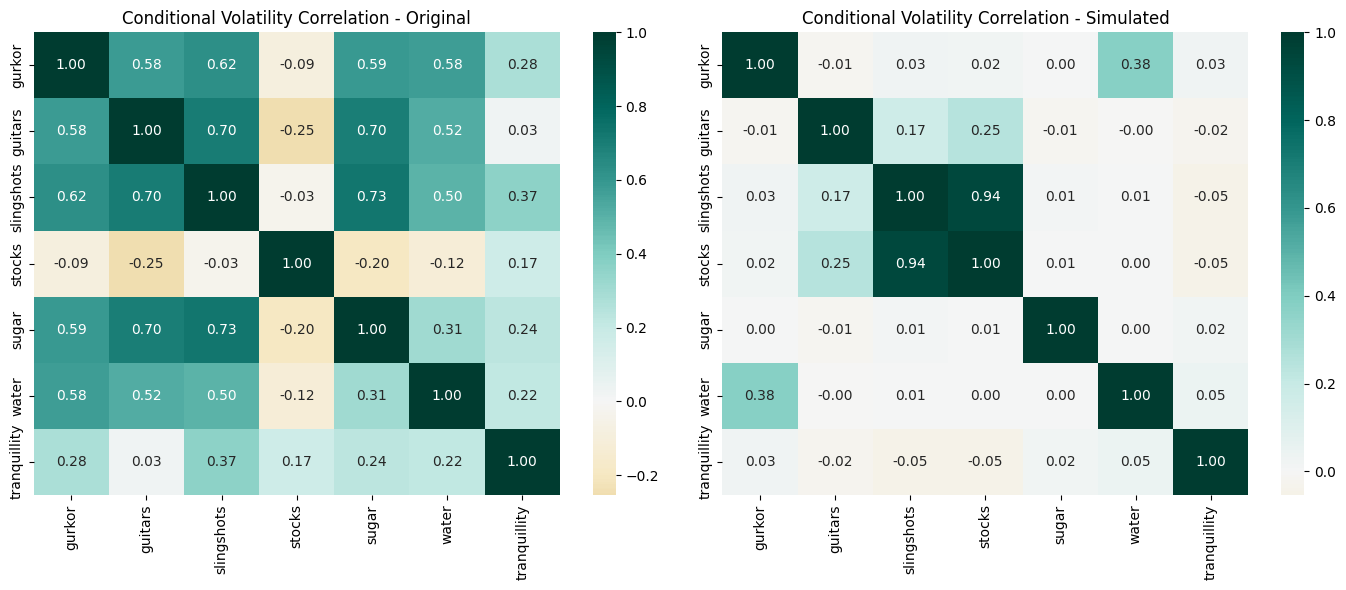

In [80]:
from arch import arch_model

# Step 1: Extract conditional variances via GARCH(1,1) for each asset
cond_vars_og = pd.DataFrame(index=df_og_returns.index)
cond_vars_sim = pd.DataFrame(index=range(len(df_returns_sim)))

for col in var_names:
    # Original
    model_og = arch_model(df_og_returns[col]*100, vol='Garch', p=1, q=1, dist='t')
    res_og = model_og.fit(disp='off')
    cond_vars_og[col] = res_og.conditional_volatility  # sigma_t, not sigma_t^2

    # Simulated
    model_sim = arch_model(df_returns_sim[col]*100, vol='Garch', p=1, q=1, dist='t')
    res_sim = model_sim.fit(disp='off')
    cond_vars_sim[col] = res_sim.conditional_volatility

# Step 2: Correlate the conditional volatilities
print("Conditional Volatility Correlation - Original:")
print(cond_vars_og.corr().round(3))

print("\nConditional Volatility Correlation - Simulated:")
print(cond_vars_sim.corr().round(3))

# Step 3: Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.heatmap(cond_vars_og.corr(), annot=True, cmap=THEME, 
            center=0, fmt=".2f", ax=axes[0])
axes[0].set_title('Conditional Volatility Correlation - Original')

sns.heatmap(cond_vars_sim.corr(), annot=True, cmap=THEME, 
            center=0, fmt=".2f", ax=axes[1])
axes[1].set_title('Conditional Volatility Correlation - Simulated')
plt.tight_layout()
plt.show()

Unconditional correlation of standardized residuals:
              gurkor  guitars  slingshots  stocks  sugar  water  tranquillity
gurkor         1.000   -0.307      -0.273  -0.038 -0.085  0.658        -0.136
guitars       -0.307    1.000       0.570   0.027  0.220 -0.340         0.243
slingshots    -0.273    0.570       1.000   0.005  0.123 -0.233         0.194
stocks        -0.038    0.027       0.005   1.000 -0.010 -0.041         0.006
sugar         -0.085    0.220       0.123  -0.010  1.000 -0.103         0.130
water          0.658   -0.340      -0.233  -0.041 -0.103  1.000        -0.165
tranquillity  -0.136    0.243       0.194   0.006  0.130 -0.165         1.000


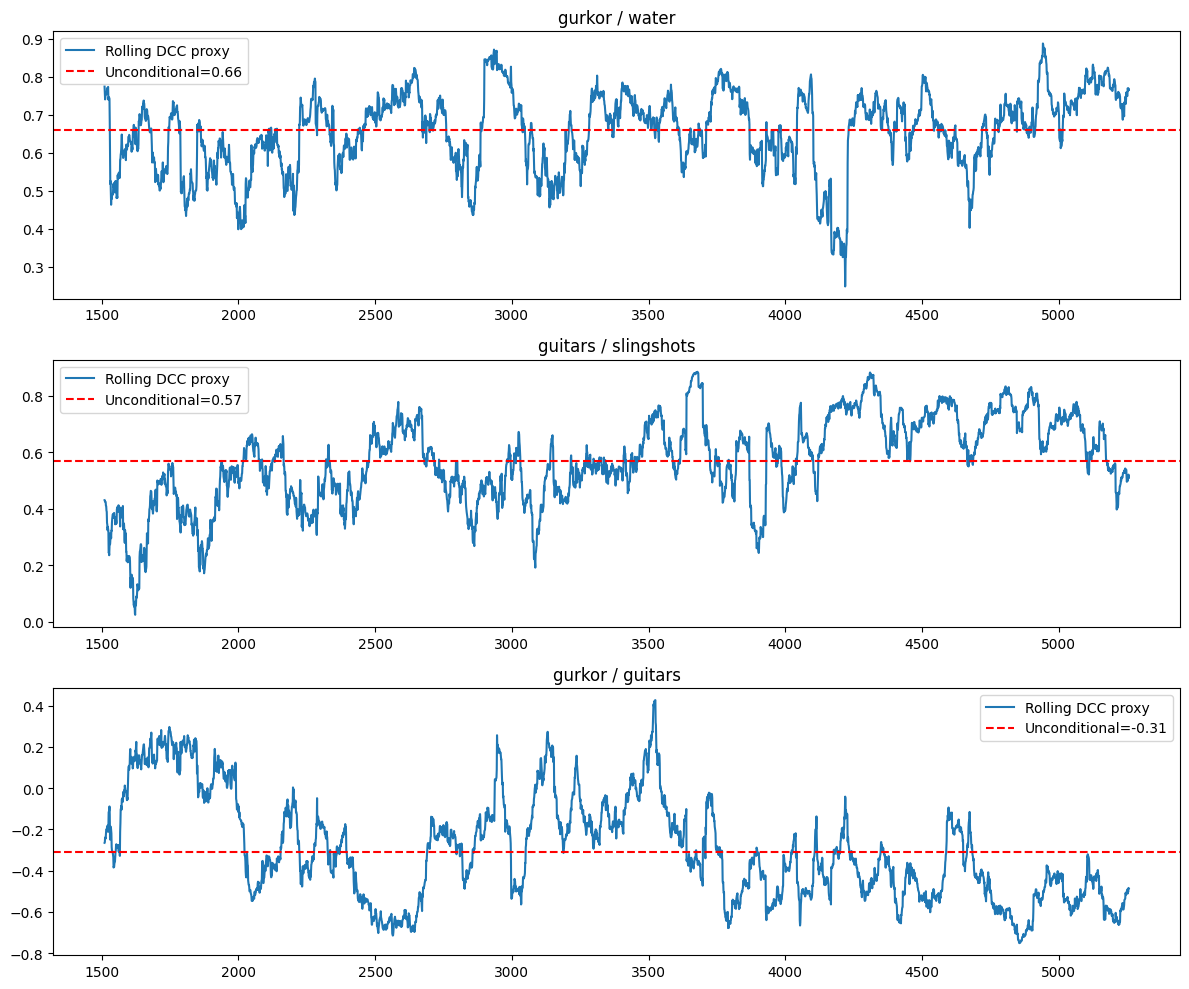

In [101]:
# Manual two-step DCC (Engle 2002)
from arch import arch_model
import numpy as np

# Step 1: Fit univariate GARCH on each series, extract standardized residuals
std_resids = pd.DataFrame(index=df_og_returns.index)
cond_vols = pd.DataFrame(index=df_og_returns.index)

for col in var_names:
    model = arch_model(df_og_returns[col] * 100, vol='Garch', p=1, q=1, dist='t')
    res = model.fit(disp='off')
    std_resids[col] = res.resid / res.conditional_volatility
    cond_vols[col] = res.conditional_volatility

# Step 2: Correlate the standardized residuals
# This is the DCC "unconditional correlation" matrix Q_bar
Q_bar = std_resids.corr()

print("Unconditional correlation of standardized residuals:")
print(Q_bar.round(3))

# Step 3: Compute rolling correlation of std residuals (proxy for time-varying DCC)
window = 60
fig, axes = plt.subplots(3, 1, figsize=(12, 10))
pairs = [('gurkor', 'water'), ('guitars', 'slingshots'), ('gurkor', 'guitars')]

for ax, (a, b) in zip(axes, pairs):
    roll_corr = std_resids[[a, b]].rolling(window).corr().unstack()[a][b]
    ax.plot(roll_corr, label='Rolling DCC proxy')
    ax.axhline(Q_bar.loc[a,b], color='red', linestyle='--', 
               label=f'Unconditional={Q_bar.loc[a,b]:.2f}')
    ax.set_title(f'{a} / {b}')
    ax.legend()
plt.tight_layout()
plt.show()

Detta är intressant! den standardiserade resten är fortfarande korrelerad -> det är factors inte individuella processer som skapar volatiliteten eller?

Se nedan: 

In [102]:
# Right approach: fit GARCH on the factors, not on Y
std_resids_factors = pd.DataFrame()
cond_vols_factors = pd.DataFrame()

for i in range(7):
    factor_series = pd.Series(F[:, i]) * 10  # scale
    model = arch_model(factor_series, vol='Garch', p=1, q=1, dist='t')
    res = model.fit(disp='off')
    std_resids_factors[f'F{i}'] = res.resid / res.conditional_volatility
    cond_vols_factors[f'F{i}'] = res.conditional_volatility

# Now check: are factor residuals still correlated?
print("Correlation of FACTOR standardized residuals:")
print(std_resids_factors.corr().round(3))
# These should be near-zero if the factor structure is correct
# because factors are supposed to be orthogonal

Correlation of FACTOR standardized residuals:
       F0     F1     F2     F3     F4     F5     F6
F0  1.000  0.035  0.023  0.020  0.003  0.058 -0.013
F1  0.035  1.000  0.025  0.074 -0.019  0.026  0.020
F2  0.023  0.025  1.000  0.019 -0.011  0.008 -0.002
F3  0.020  0.074  0.019  1.000 -0.023  0.013  0.026
F4  0.003 -0.019 -0.011 -0.023  1.000  0.031 -0.020
F5  0.058  0.026  0.008  0.013  0.031  1.000 -0.026
F6 -0.013  0.020 -0.002  0.026 -0.020 -0.026  1.000


jag tror att detta innebär att det INTE är faktorerna som styr volatiliteten. Vi måste därmed gå tillbaka till de individuella tidsserierna.

Hmmm kanske styrs de av latent factors i sig !?

Variance explained by volatility factors:
  Vol-PC1: 0.501 (50.1%)
  Vol-PC2: 0.150 (15.0%)
  Vol-PC3: 0.124 (12.4%)
  Vol-PC4: 0.113 (11.3%)
  Vol-PC5: 0.055 (5.5%)
  Vol-PC6: 0.031 (3.1%)
  Vol-PC7: 0.025 (2.5%)

Cumulative: [0.501 0.651 0.775 0.889 0.944 0.975 1.   ]


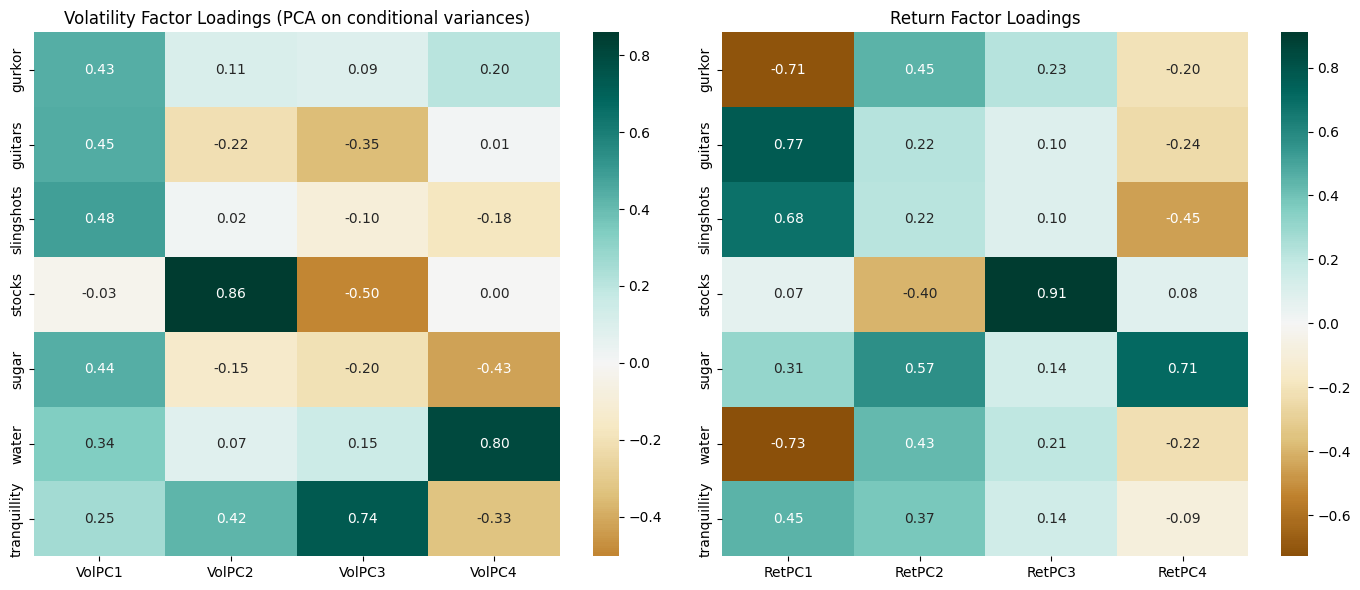

In [103]:
# Step 1: Extract conditional variances for each observed series
cond_vars = pd.DataFrame()

for col in var_names:
    res = arch_model(df_og_returns[col] * 1000, 
                     vol='Garch', p=1, q=1, dist='t').fit(disp='off')
    cond_vars[col] = res.conditional_volatility**2  # variance not vol

# Step 2: Run PCA on the conditional variances
# This finds the common volatility factors
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
cond_vars_scaled = scaler.fit_transform(cond_vars)

pca_vol = PCA()
pca_vol.fit(cond_vars_scaled)

print("Variance explained by volatility factors:")
for i, v in enumerate(pca_vol.explained_variance_ratio_):
    print(f"  Vol-PC{i+1}: {v:.3f} ({v*100:.1f}%)")

# Step 3: How many volatility factors do you need?
cumvar = np.cumsum(pca_vol.explained_variance_ratio_)
print(f"\nCumulative: {np.round(cumvar, 3)}")

# Step 4: Loadings - which assets load on which vol factor?
vol_loadings = pd.DataFrame(
    pca_vol.components_.T,
    index=var_names,
    columns=[f'VolPC{i+1}' for i in range(7)]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(vol_loadings.iloc[:, :4], annot=True, cmap=THEME,
            center=0, fmt=".2f", ax=axes[0])
axes[0].set_title('Volatility Factor Loadings (PCA on conditional variances)')

# Compare with return factor loadings
sns.heatmap(pd.DataFrame(Lambda_corrected, index=var_names,
            columns=[f'RetPC{i+1}' for i in range(7)]).iloc[:, :4],
            annot=True, cmap=THEME, center=0, fmt=".2f", ax=axes[1])
axes[1].set_title('Return Factor Loadings')

plt.tight_layout()
plt.show()

In [104]:
# Correct scaling: arch recommends value between 1-1000
# Factors are large (~1e4), so scale down
factor_scale = 10

garch_params = {}
for i in range(7):
    factor_series = pd.Series(F[:, i]) * factor_scale
    model = arch_model(factor_series, vol='Garch', p=1, q=1, dist='t')
    res = model.fit(disp='off')
    garch_params[i] = {
        'omega': res.params['omega']/ factor_scale**2,  # rescale back
        'alpha': res.params['alpha[1]'],
        'beta': res.params['beta[1]'],
        'nu': res.params['nu'],
        'persistence': res.params['alpha[1]'] + res.params['beta[1]']
    }

# Print summary
summary = pd.DataFrame(garch_params).T
summary.index = [f'F{i}' for i in range(7)]
print(summary.round(4))
print(f"\nAll persistence (alpha+beta) < 1: {(summary['persistence'] < 1).all()}")

     omega   alpha    beta        nu  persistence
F0  0.0095  0.0051  0.9858   44.0171       0.9910
F1  1.0849  0.0127  0.0000   79.4307       0.0127
F2  0.0190  0.0000  0.9812   64.3650       0.9812
F3  0.8047  0.0552  0.1983  125.7926       0.2536
F4  0.8423  0.0043  0.1709   98.8637       0.1753
F5  0.9961  0.0831  0.0000  123.0425       0.0831
F6  1.0335  0.0224  0.0000  146.6895       0.0224

All persistence (alpha+beta) < 1: True


In [105]:
from scipy.stats import t as student_t

print("Empirical nu estimates from factor standardized residuals:")
for i in range(7):
    factor_series = pd.Series(F[:, i]) * factor_scale
    model = arch_model(factor_series, vol='Garch', p=1, q=1, dist='t')
    res = model.fit(disp='off')
    
    # Standardized residuals = pure innovations stripped of GARCH variance
    std_innov = res.std_resid  # resid / conditional_volatility
    
    # Fit t-distribution to these
    nu_fit, _, _ = student_t.fit(std_innov, floc=0, fscale=1)
    nu_garch = res.params['nu']  # what GARCH estimated
    
    print(f"  F{i}: scipy nu={nu_fit:.2f}, GARCH nu={nu_garch:.2f}")

Empirical nu estimates from factor standardized residuals:
  F0: scipy nu=114.85, GARCH nu=44.02
  F1: scipy nu=2434.38, GARCH nu=79.43
  F2: scipy nu=210.18, GARCH nu=64.36
  F3: scipy nu=2032.60, GARCH nu=125.79
  F4: scipy nu=250.22, GARCH nu=98.86
  F5: scipy nu=4398046511104.96, GARCH nu=123.04
  F6: scipy nu=4398046511104.96, GARCH nu=146.69


In [106]:
# Theoretical kurtosis from GARCH(1,1) with Gaussian innovations
# Formula: kurtosis = 6*alpha^2 / (1 - (alpha+beta)^2 - 2*alpha^2)

print("Theoretical kurtosis from GARCH parameters:")
for i, p in garch_params.items():
    a = p['alpha']
    b = p['beta']
    denom = 1 - (a+b)**2 - 2*a**2
    if denom > 0:
        kurt = 6*a**2 / denom
        print(f"  F{i}: theoretical excess kurtosis = {kurt:.3f}")
    else:
        print(f"  F{i}: kurtosis undefined (persistence too high)")

for i, p in garch_params.items():
    print(f"F{i}: alpha={p['alpha']:.4f}, beta={p['beta']:.4f}, "
          f"persistence={p['alpha']+p['beta']:.4f}")

Theoretical kurtosis from GARCH parameters:
  F0: theoretical excess kurtosis = 0.009
  F1: theoretical excess kurtosis = 0.001
  F2: theoretical excess kurtosis = 0.000
  F3: theoretical excess kurtosis = 0.020
  F4: theoretical excess kurtosis = 0.000
  F5: theoretical excess kurtosis = 0.042
  F6: theoretical excess kurtosis = 0.003
F0: alpha=0.0051, beta=0.9858, persistence=0.9910
F1: alpha=0.0127, beta=0.0000, persistence=0.0127
F2: alpha=0.0000, beta=0.9812, persistence=0.9812
F3: alpha=0.0552, beta=0.1983, persistence=0.2536
F4: alpha=0.0043, beta=0.1709, persistence=0.1753
F5: alpha=0.0831, beta=0.0000, persistence=0.0831
F6: alpha=0.0224, beta=0.0000, persistence=0.0224


In [110]:
# Model volatility at the OBSERVED level, then back out implications
# Rather than: Y = Lambda @ F_garch  (GARCH on factors)
# Do:          fit GARCH on Y directly, simulate Y_garch, done

cond_vols_og = pd.DataFrame(index=df_og_returns.index)
garch_params_obs = {}

for col in var_names:
    model = arch_model(df_og_returns[col] * 1000, 
                       vol='Garch', p=1, q=1, dist='normal')
    res = model.fit(disp='off')
    garch_params_obs[col] = {
        'omega': res.params['omega'],
        'alpha': res.params['alpha[1]'],
        'beta': res.params['beta[1]'],
        'persistence': res.params['alpha[1]'] + res.params['beta[1]']
    }
    cond_vols_og[col] = res.conditional_volatility
    print(f"{col}: alpha={res.params['alpha[1]']:.4f}, "
          f"omega= {res.params['omega']:.4f} "
          f"beta={res.params['beta[1]']:.4f}, "
          f"persistence={res.params['alpha[1]']+res.params['beta[1]']:.4f}")

gurkor: alpha=0.0354, omega= 0.0600 beta=0.9610, persistence=0.9965
guitars: alpha=0.0825, omega= 2.3800 beta=0.9076, persistence=0.9901
slingshots: alpha=0.0866, omega= 5.1221 beta=0.8897, persistence=0.9763
stocks: alpha=0.0000, omega= 4.7448 beta=0.9787, persistence=0.9787
sugar: alpha=0.0844, omega= 3.9366 beta=0.9000, persistence=0.9844
water: alpha=0.0320, omega= 0.0581 beta=0.9632, persistence=0.9952
tranquillity: alpha=0.0403, omega= 1.0458 beta=0.9545, persistence=0.9948


Persistance is high across the board for the actual observed series, so this makes us believe that this creates the kurtosis and is the source of vol

In [ ]:
TODO:

Lägg in stokastisk volatilitet som också tar hänsyn 
till korrelation i volatilitet så individuella processer

Ändra från gaussian shocks till något med mer tail!